In [2]:
import numpy as np
import torch
from torch import nn
from evolml.utils import PytorchModelEncoding, PytorchModelInitializer
from evolml.models import RBFLayer
import metaheuristic_designer as mhd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

In [6]:
algorithm_name = "PSO"

In [13]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.f1 = nn.Linear(1, 30)
        self.f2 = nn.Linear(30, 40)
        self.f3 = nn.Linear(40, 30)
        self.f4 = nn.Linear(30, 20)
        self.f5 = nn.Linear(20, 1)

        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.f1(x))
        x = self.activ(self.f2(x))
        x = self.activ(self.f3(x))
        x = self.activ(self.f4(x))

        return self.f5(x)

class EvalTorchModel(mhd.VectorObjectiveFunc):
    def __init__(self, model_base, loss_fn, X, y, mode="min", name="Torch model evaluation"):
        n_params = sum(p.numel() for p in model_base.parameters() if p.requires_grad)
        super().__init__(vecsize=n_params, mode=mode, name=name, low_lim=-10, up_lim=10)
        self.model_base = model_base
        self.loss_fn = loss_fn
        self.X = X
        self.y = y
    
    @torch.no_grad()
    def objective(self, model):
        pred = model(self.X)
        return self.loss_fn(pred, self.y).item()

X = torch.linspace(-2*torch.pi, 2*torch.pi, 10000).reshape((10000, 1))
y = torch.sinc(X)

model_base = MLP()
loss_fn = nn.MSELoss()

params = {
    "stop_cond": "convergence or time_limit",
    "progress_metric": "time_limit",
    "time_limit": 100.0,
    "cpu_time_limit": 100.0,
    "ngen": 1000,
    "neval": 3e6,
    "fit_target": 1e-10,
    "patience": 40,
    "verbose": True,
    "v_timer": 0.5,
}
objfunc = EvalTorchModel(model_base, loss_fn, X, y)
torch_encoding = PytorchModelEncoding(model_base)
print(pop_init.generate_random().shape[0] * 5e-3)

match algorithm_name:
    case "PSO":
        pso_encoding = mhd.encodings.CompositeEncoding(
            [torch_encoding, mhd.encodings.PSOEncoding(objfunc.vecsize)]
        )
        pop_init = mhd.ExtendedInitializer(
            solution_init=PytorchModelInitializer(model_base, pop_size=100, encoding=torch_encoding),
            param_init_dict={
                "speed": mhd.initializers.UniformInitializer(objfunc.vecsize, -10, 10)
            },
            encoding=pso_encoding
        )
        search_strat = mhd.strategies.PSO(encoding=pso_encoding, initializer=pop_init, params={"w": 0.8, "c1": 1.5, "c2": 1.5})
    case "RandomSearch":
        pop_init = PytorchModelInitializer(model_base, pop_size=100, encoding=torch_encoding)
        search_strat = mhd.strategies.RandomSearch(pop_init)
    case "HillClimb":
        pop_init = PytorchModelInitializer(model_base, pop_size=1, encoding=torch_encoding)
        search_strat = mhd.strategies.HillClimb(pop_init, mhd.operators.VectorOperator("RandNoise", {"distrib": "gauss", "F": 1e-1, "N": 100}))
    case "SA":
        pop_init = PytorchModelInitializer(model_base, pop_size=1, encoding=torch_encoding)
        search_strat = mhd.strategies.SA(pop_init, mhd.operators.VectorOperator("RandNoise", {"distrib": "gauss", "F": 1e-2, "N": 50}), params={"iter": 100, "temp_init": 1, "alpha": 0.90})
    case "DE":
        pop_init = PytorchModelInitializer(model_base, pop_size=100, encoding=torch_encoding)
        search_strat = mhd.strategies.DE(pop_init, mhd.operators.VectorOperator("DE/current-to-best/1", {"F": 0.8, "Cr": 0.8, "p": 0.1}))
    case "ES":
        pop_init = PytorchModelInitializer(model_base, pop_size=100, encoding=torch_encoding)
        search_strat = mhd.strategies.ES(
            pop_init,
            mhd.operators.VectorOperator("MutNoise", {"distrib": "gauss", "F": 1e-2, "Cr": 5e-3}),
            # mhd.operators.VectorOperator("Multipoint"),
            mhd.NullOperator(),
            mhd.selection_methods.NullParentSelection(),
            mhd.selection_methods.SurvivorSelection("(m+n)"),
            params={"offspringSize": 500}
        )
    case "GA":
        search_strat = mhd.strategies.GA(
            pop_init,
            mhd.operators.VectorOperator("MutNoise", {"distrib": "gauss", "F": 1e-2, "Cr": 5e-3}),
            mhd.operators.VectorOperator("Multipoint"),
            mhd.selection_methods.ParentSelection("Best", {"amount": 50}),
            mhd.selection_methods.SurvivorSelection("Elitism", {"amount": 100})
        )

algorithm = mhd.GeneralAlgorithm(objfunc, search_strat, params=params)

31.71


In [14]:
result = algorithm.optimize()
ind, fit = result.best_solution()
best_model, _ = result.best_solution(decoded=True)

Initializing optimization of Torch model evaluation using PSO
-------------------------------------------------------------



TypeError: list indices must be integers or slices, not tuple

torch.Size([10000, 1])


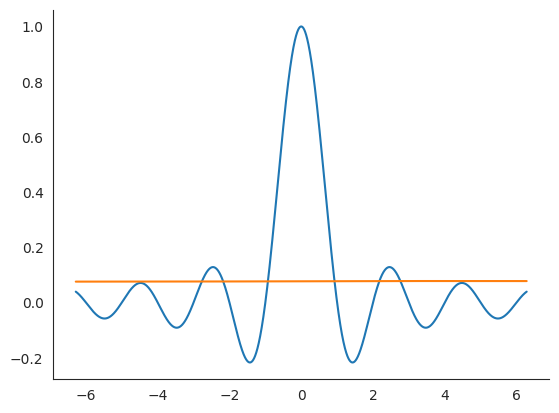

In [ ]:
pred = best_model(X).detach()
print(pred.shape)

plt.plot(X, y)
plt.plot(X, pred)
sns.despine()